17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Train shape: (25000,) (25000,)
Test shape: (25000,) (25000,)
After padding: (25000, 250) (25000, 250)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 250, 64)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 390,209 (1.49 MB)

 Trainable params: 390,209 (1.49 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 188s 469ms/step - accuracy: 0.6967 - loss: 0.5800 - val_accuracy: 0.7728 - val_loss: 0.4989
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 182s 467ms/step - accuracy: 0.8096 - loss: 0.4474 - val_accuracy: 0.8167 - val_loss: 0.4213
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 178s 457ms/step - accuracy: 0.8300 - loss: 0.4137 - val_accuracy: 0.8412 - val_loss: 0.3992
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 179s 459ms/step - accuracy: 0.8628 - loss: 0.3505 - val_accuracy: 0.8394 - val_loss: 0.3755
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 180s 462ms/step - accuracy: 0.8773 - loss: 0.3197 - val_accuracy: 0.8175 - val_loss: 0.4101
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 182s 466ms/step - accuracy: 0.8918 - loss: 0.2867 - val_accuracy: 0.8381 - val_loss: 0.3979
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 181s 464ms/step - accuracy: 0.9021 - loss: 0.2662 - val_accuracy: 0.8438 - val_loss: 0.4066
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 180s 460ms/step - accuracy: 0.9088 -

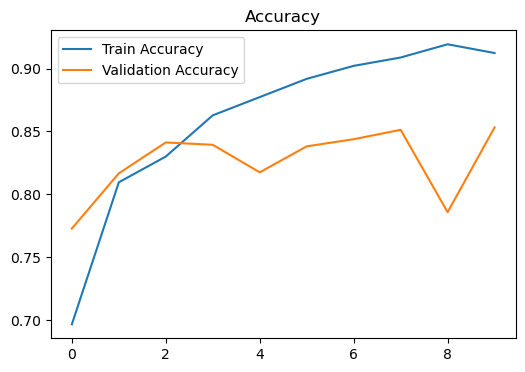

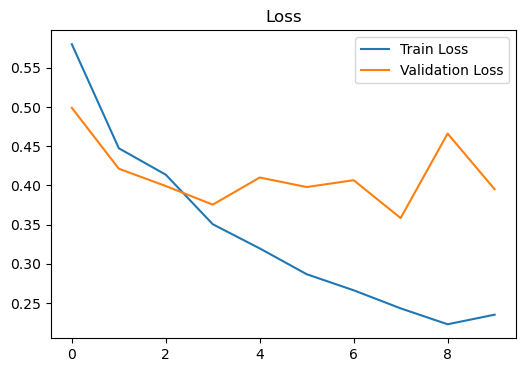

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 518ms/step

Prediction: Negative Sentiment
Actual Label: 0


In [1]:
# ===============================
# 1. IMPORT LIBRARIES
# ===============================
import numpy as np
import pandas as pd
from tensorflow import keras
import matplotlib.pyplot as plt

# ===============================
# 2. LOAD DATA
# ===============================
imdb = keras.datasets.imdb

# Use top 5000 most frequent words
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=5000)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

# ===============================
# 3. PAD SEQUENCES
# ===============================
maxlen = 250

X_train = keras.utils.pad_sequences(X_train, padding='post', maxlen=maxlen)
X_test = keras.utils.pad_sequences(X_test, padding='post', maxlen=maxlen)

print("After padding:", X_train.shape, X_test.shape)

# ===============================
# 4. BUILD LSTM MODEL
# ===============================
def build_model():
    model = keras.Sequential([
        keras.layers.Input(shape=(maxlen,)),

        # Better embedding size
        keras.layers.Embedding(input_dim=5000, output_dim=64),

        # Bidirectional LSTM (BIG improvement)
        keras.layers.Bidirectional(
            keras.layers.LSTM(64, dropout=0.2, recurrent_dropout=0.2)
        ),

        # Dense layers
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dropout(0.3),

        keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

model = build_model()
model.summary()

# ===============================
# 5. TRAIN MODEL
# ===============================
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test)
)

# ===============================
# 6. EVALUATE MODEL
# ===============================
loss, acc = model.evaluate(X_test, y_test)
print("\nTest Loss:", loss * 100)
print("Test Accuracy:", acc * 100)

# ===============================
# 7. PLOT RESULTS
# ===============================
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Accuracy plot
plt.figure(figsize=(6,4))
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()
plt.show()

# Loss plot
plt.figure(figsize=(6,4))
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Loss')
plt.legend()
plt.show()

# ===============================
# 8. PREDICT ON NEW REVIEW
# ===============================

# Example: random test review
index = np.random.randint(0, len(X_test))
sample_review = X_test[index]
sample_review = np.array([sample_review])

prediction = model.predict(sample_review)

if prediction > 0.5:
    print("\nPrediction: Positive Sentiment")
else:
    print("\nPrediction: Negative Sentiment")

print("Actual Label:", y_test[index])